In [1]:
from CrocoDash.grid import Grid

grid = Grid(
  resolution = 0.05, # in degrees
  xstart = 278.0, # min longitude in [0, 360]
  lenx = 3.0, # longitude extent in degrees
  ystart = 7.0, # min latitude in [-90, 90]
  leny = 3.0, # latitude extent in degrees
  name = "panama1",
)

## Step 1.2: Topography

In [2]:
from CrocoDash.topo import Topo

topo = Topo(
    grid = grid,
    min_depth = 9.5, # in meters
)

In [3]:
from pathlib import Path

bathymetry_path= Path("/Users/manishrv/Documents/data/croc/gebco/GEBCO_2024.nc")
# The GEBCO bathymetry path on Derecho is: <GEBCO>

if not bathymetry_path.exists():
    raise FileNotFoundError("Bathymetry file not found, please replace with path to bathymetry file")

topo.set_from_dataset(
    bathymetry_path = bathymetry_path,
    longitude_coordinate_name="lon",
    latitude_coordinate_name="lat",
    vertical_coordinate_name="elevation"
)

**NOTE**
            If bathymetry setup fails (e.g. kernel crashes), restart the kernel and edit this cell.
            Call ``[topo_object_name].mpi_set_from_dataset()`` instead. Follow the given instructions for using mpi
            and ESMF_Regrid outside of a python environment. This breaks up the process, so be sure to call
            ``[topo_object_name].tidy_dataset() after regridding with mpi.
Begin regridding dataset...

Original dataset size: 7.39 Mb
Regridded size: 0.09 Mb



/Users/manishrv/miniconda3/envs/CrocoDash/lib/python3.11/site-packages/xesmf/backend.py:42: UserWarning: Input array is not F_CONTIGUOUS. Will affect performance.
  warnings.warn('Input array is not F_CONTIGUOUS. ' 'Will affect performance.')


Tidy bathymetry: Reading in regridded bathymetry to fix up metadata...done. Filling in inland lakes and channels... 

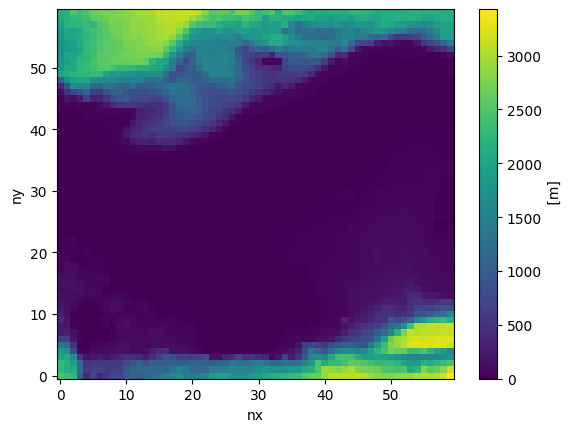

In [4]:
topo.depth.plot()

## Step 1.3: Vertical Grid

In [6]:
from CrocoDash.vgrid import VGrid

vgrid  = VGrid.hyperbolic(
    nk = 75, # number of vertical levels
    depth = topo.max_depth,
    ratio=20.0 # target ratio of top to bottom layer thicknesses
)

In [8]:
from pathlib import Path

In [12]:
# CESM case (experiment) name
casename = "panama-crocontainer"

# CESM source root (Update this path accordingly!!!)
cesmroot ="/Users/manishrv/CROCESM_workshop_2025"

# Place where all your input files go 
inputdir = f"/Users/manishrv/croc_input/{casename}"
    
# CESM case directory
caseroot = f"/Users/manishrv/croc_cases/{casename}"

## Step 2.2: Create the Case

To create the CESM case, instantiate the `Case` object as shown below. This will automatically set up the CESM case based on the provided inputs: The `cesmroot` argument specifies the path to your local CESM source directory.
The `caseroot` argument defines the directory where the case will be created. CrocoDash will handle all necessary namelist modifications and XML changes to align with the MOM6 domain objects generated earlier.

In [15]:
from CrocoDash.case import Case
import os
os.environ["CIME_MACHINE"] = "ubuntu-latest"
case = Case(
    cesmroot = cesmroot,
    caseroot = caseroot,
    inputdir = inputdir,
    ocn_grid = grid,
    ocn_vgrid = vgrid,
    ocn_topo = topo,
    project = 'CESM0030',
    override = True,
    machine = "homebrew",
    compset = "CR_JRA" # This is the alias of the compset, the longname (which is printed when you run this command) is 1850_DATM%JRA_SLND_SICE_MOM6%REGIONAL_SROF_SGLC_SWAV. Feel free to use either way!
)

INFO:	initialize:Initializing the visualCaseGen system...
INFO:  csp_solver:CspSolver initialized.


Creating case...

• Updating ccs_config/modelgrid_aliases_nuopc.xml file to include the new resolution "panama-crocontainer" consisting of the following component grids.
 atm grid: "TL319" 
 lnd grid: "TL319" 
 ocn grid: "panama1".
 rof grid: "null".

• Updating ccs_config/component_grids_nuopc.xml file to include newly generated ocean grid "panama1" with the following properties:
 nx: 60, ny: 60. ocean mesh: /Users/manishrv/croc_input/panama-crocontainer/ocnice/ESMF_mesh_panama1_ee7f1f.nc.

Running the create_newcase tool with the following command:

/Users/manishrv/CROCESM_workshop_2025/cime/scripts/create_newcase --compset CR_JRA --res panama-crocontainer --case /Users/manishrv/croc_cases/panama-crocontainer --machine homebrew --run-unsupported --project CESM0030 --non-local 

The create_newcase command was successful.

Navigating to the case directory:

cd /Users/manishrv/croc_cases/panama-crocontainer

Running the case.setup script with the following command:

./case.setup --non-l

INFO:	stage:SUCCESS: All stages are complete.


Case created successfully at /Users/manishrv/croc_cases/panama-crocontainer.

To further customize, build, and run the case, navigate to the case directory in your terminal. To create another case, restart the notebook.

./xmlchange MOM6_MEMORY_MODE=dynamic_symmetric --non-local



# Section 3: Prepare ocean forcing data

We need to cut out our ocean forcing. The package expects an initial condition and one time-dependent segment per non-land boundary. Naming convention is `"east_unprocessed"` for segments and `"ic_unprocessed"` for the initial condition.

In this notebook, we are forcing with the Copernicus Marine "Glorys" reanalysis dataset. There's a function in the `CrocoDash` package, called `configure_forcings`, that generates a bash script to download the correct boundary forcing files for your experiment. First, you will need to create an account with Copernicus, and then call `copernicusmarine login` to set up your login details on your machine. Then you can run the `get_glorys_data.sh` bash script.

## Step 3.1 Configure Initial Conditions and Forcings


In [16]:
case.configure_forcings(
    date_range = ["2020-01-01 00:00:00", "2020-01-05 00:00:00"],
    function_name="get_glorys_data_from_cds_api"
)

INFO:CrocoDash.forcing_configurations.base:[SKIP] tides missing args: ['tpxo_elevation_filepath', 'tpxo_velocity_filepath', 'tidal_constituents']
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGC incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] CICE incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGCIC incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGCIronForcing incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] BGCRiverNutrients incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] Runoff incompatible with compset
INFO:CrocoDash.forcing_configurations.base:[SKIP] Chl missing args: ['chl_processed_filepath']


Adding parameter changes to user_nl_mom:

  ! Initial conditions
  INIT_LAYERS_FROM_Z_FILE = True
  Z_INIT_ALE_REMAPPING = True
  TEMP_SALT_INIT_VERTICAL_REMAP_ONLY = True
  DEPRESS_INITIAL_SURFACE = True
  VELOCITY_CONFIG = file
  TEMP_SALT_Z_INIT_FILE = init_tracers.nc
  SURFACE_HEIGHT_IC_FILE = init_eta.nc
  VELOCITY_FILE = init_vel.nc
  Z_INIT_FILE_PTEMP_VAR = temp
  Z_INIT_FILE_SALT_VAR = salt
  SURFACE_HEIGHT_IC_VAR = eta_t
  U_IC_VAR = u
  V_IC_VAR = v

  ! Open boundary conditions
  OBC_NUMBER_OF_SEGMENTS = 4
  OBC_FREESLIP_VORTICITY = False
  OBC_FREESLIP_STRAIN = False
  OBC_COMPUTED_VORTICITY = True
  OBC_COMPUTED_STRAIN = True
  OBC_ZERO_BIHARMONIC = True
  OBC_TRACER_RESERVOIR_LENGTH_SCALE_OUT = 3.0E+04
  OBC_TRACER_RESERVOIR_LENGTH_SCALE_IN = 3000.0
  BRUSHCUTTER_MODE = True
  OBC_SEGMENT_001 = "J=0,I=0:N,FLATHER,ORLANSKI,NUDGED,ORLANSKI_TAN,NUDGED_TAN"
  OBC_SEGMENT_001_VELOCITY_NUDGING_TIMESCALES = 0.3, 360.0
  OBC_SEGMENT_001_DATA = "U=file:forcing_obc_segment_001.nc(u

##  Step 3.3: Process forcing data

In this final step, we call the `process_forcings` method of CrocoDash to cut out and interpolate the initial condition as well as all boundaries. CrocoDash also updates MOM6 runtime parameters and CESM xml variables accordingly.

In [17]:
case.process_forcings()

INFO:CrocoDash.extract_forcings.regrid_dataset_piecewise:Parsing Raw Data Folder


FileNotFoundError: [Errno 2] No such file or directory: '/Users/manishrv/croc_input/panama-crocontainer/extract_forcings/raw_data'

In [ ]:
print("You can now build and run your case at",caseroot)

# Section 4: Build and run the case

After completing the previous steps, you are ready to build and run your CESM case. Begin by navigating to the case root directory specified during the case creation. Before proceeding, review the `user_nl_mom` file located in the case directory. This file contains MOM6 parameter settings that were automatically generated by CrocoDash. Carefully examine these parameters and make any necessary adjustments to fine-tune the model for your specific requirements. While CrocoDash aims to provide a solid starting point, further tuning and adjustments are typically necessary to improve the model for your use case.

Once you have reviewed and modified the parameters as needed, you can build and execute the case using the following commands: 
```
qcmd -- ./case.build
./case.submit
```